In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: NVIDIA RTX 4000 Ada Generation


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: DeepLabv3+ (Encoder-Decoder with ASPP)
# Target Backbone: Modified Aligned Xception 
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION STUDY - NO BACKBONE FREEZING (AB1)
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB/24GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP & Checkpointing)
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Toolchain Version: {torch.version.cuda}")
    print(f"Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"TF32 configuration skipped: {e}")

# --------------------------------------------------
# AMP Setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Training Enabled: {USE_AMP}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
# 1. Dataset Roots
IMG_ROOT = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit").expanduser()
MASK_ROOT = Path("~/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine").expanduser()

# 2. Main Output Root for Ablation Study
OUTPUT_DIR = Path("~/Pictures/deeplabv3+_cityscapes").expanduser()

FINAL_SAVE_DIR = OUTPUT_DIR / "Results_Export_deeplabv3+_cityscapes"
QUAL_VIS_DIR = OUTPUT_DIR / "training_visuals_deeplabv3+_cityscapes"

# 3. Local Working Directories (Routed inside the AB1 folder)
CHECKPOINT_DIR = OUTPUT_DIR / "progressive_checkpoints_deeplabv3+_cityscapes"
PLOTS_DIR = OUTPUT_DIR / "training_plots_deeplabv3+_cityscapes"
LOGS_DIR = OUTPUT_DIR / "training_logs_deeplabv3+_cityscapes"
METRICS_DIR = OUTPUT_DIR / "training_metrics_deeplabv3+_cityscapes"

# Safely build all target directories
for d in [OUTPUT_DIR, CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "DeepLabv3+ (Modified Aligned Xception)"
MODEL_ALIAS = "DeepLabv3+ (NO BACKBONE FREEZING)"

print(f"\nModel Configuration Linked: {MODEL_ALIAS}")
print(f"Custom Architecture Base: {MODEL_NAME}")
print(f"Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    # Training Loop Loss Tracking
    "train_total_loss": [],
    "train_ce_loss": [],
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    # Validation Evaluation Metrics
    "val_total_loss": [], 
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    # Optimizer State Records
    "backbone_lr": [],
    "head_lr": [],
    "epoch_time_sec": []
}

best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_deeplabv3plus_checkpoint.pt"),
    "latest_path": str(CHECKPOINT_DIR / "latest_deeplabv3plus_checkpoint.pt")
}

print("Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU Model: NVIDIA RTX 4000 Ada Generation
CUDA Toolchain Version: 12.6
Total Available GPU Memory: 19.67 GB
TF32 matrix operations enabled successfully.
Mixed Precision Training Enabled: True

Model Configuration Linked: DeepLabv3+ (NO BACKBONE FREEZING)
Custom Architecture Base: DeepLabv3+ (Modified Aligned Xception)
Global Analytical Results Save Path Linked: /home/ubuntu/Pictures/deeplabv3+_cityscapes/Results_Export_deeplabv3+_cityscapes
Checkpoints will be saved to: /home/ubuntu/Pictures/deeplabv3+_cityscapes/progressive_checkpoints_deeplabv3+_cityscapes
Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: DeepLabv3+ (Encoder-Decoder)
# Target Dataset: Cityscapes
# Optimization Mode: Strict Paper Reproduction
# ============================================================

print(f"Image root inherited: {IMG_ROOT}")
print(f"Mask root inherited : {MASK_ROOT}")
print(f"Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (Cityscapes 19-Class Standard)
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard Cityscapes RGB Color Palette
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# DEEPLABV3+ OPTIMIZATION SCHEDULE (STRICT PAPER SPECIFICATIONS)
# ------------------------------------------------------------
# DeepLabv3+ trains end-to-end without piecewise pretraining of each component[cite: 1].
BASE_LR = 0.007               # The paper employs an initial learning rate of 0.007[cite: 1].
LR_POLICY = "poly"            # The paper utilizes the "poly" policy for the learning rate schedule[cite: 1].
WEIGHT_DECAY = 4e-5           # Standard weight decay used during Xception pretraining[cite: 1].
MOMENTUM = 0.9                # Nesterov momentum optimizer value referenced in the paper[cite: 1].

TRAIN_CROP_SIZE = (513, 513)  # The paper explicitly defines a crop size of 513x513[cite: 1].
BATCH_SIZE = 16               # Standard effective batch size for segmentation. Adjust based on VRAM via Grad Accumulation.
GRAD_ACCUM_STEPS = 1          # Set higher (e.g., 4 or 8) if VRAM is constrained to maintain effective batch size.
EPOCHS = 120

# Output Stride controls feature map resolution. OS=16 strikes the best balance of speed/accuracy[cite: 1].
TRAIN_OUTPUT_STRIDE = 16 

# The paper fine-tunes batch normalization parameters when output stride = 16[cite: 1].
FREEZE_BATCHNORM_STATS = False 

print("\n--- DEEPLABV3+ TRAINING CONFIGURATION ---")
print(f"Total Training Epochs  : {EPOCHS}")
print(f"Base Learning Rate     : {BASE_LR}")
print(f"Learning Rate Schedule : {LR_POLICY} policy")
print(f"Weight Decay           : {WEIGHT_DECAY}")
print(f"Training Crop Size     : {TRAIN_CROP_SIZE}")
print(f"Output Stride (Train)  : {TRAIN_OUTPUT_STRIDE}")
print(f"Batch Norm Fine-tuning : {not FREEZE_BATCHNORM_STATS}")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS
# ------------------------------------------------------------
# DeepLabv3+ relies on standard Cross-Entropy Loss for semantic segmentation.
USE_CROSS_ENTROPY = True

print("\n--- Loss Formulation ---")
print("Using Standard Cross-Entropy Loss (DeepLabv3+ specification)")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
# To maximize performance during evaluation, the paper recommends the following:
EVAL_OUTPUT_STRIDE = 16          # Can be lowered to 8 for higher accuracy at the cost of computation[cite: 1].
USE_MULTI_SCALE_INFERENCE = True # DeepLabv3+ evaluation uses multi-scale inputs[cite: 1].
USE_FLIP_TTA = True              # DeepLabv3+ evaluation adds left-right flipped inputs[cite: 1].

print("\n--- Evaluation Strategy ---")
print(f"Output Stride (Eval)       : {EVAL_OUTPUT_STRIDE}")
print(f"Multi-Scale Inference (MS) : {USE_MULTI_SCALE_INFERENCE}")
print(f"Left-Right Flipping (Flip) : {USE_FLIP_TTA}")

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (Cityscapes Specific)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Loss Curve
    if len(history_dict.get("train_total_loss", [])) == len(epochs):
        axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    val_loss_arr = np.array(history_dict.get("val_total_loss", []))
    if len(val_loss_arr) == len(epochs) and not np.isnan(val_loss_arr).all() and not np.all(val_loss_arr == 0):
        axes[0].plot(epochs, val_loss_arr, label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    # Plot 2: mIoU Curve
    if len(history_dict.get("train_miou", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict.get("val_miou", [])) == len(epochs):
        axes[1].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('mIoU (%)', fontsize=12)
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION (Adjusted for DeepLabv3+)
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    
    # Assuming standard DataLoader output format: images and 2D target masks
    images, target_masks = batch[0], batch[1]
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(images)
            
            # DeepLabv3+ standard output handling
            if isinstance(outputs, dict):
                logits = outputs['out']
            else:
                logits = outputs
                
            # DeepLabv3+ decoder output is upsampled by a factor of 4[cite: 1].
            # We interpolate back to the native image resolution for evaluation.
            if logits.shape[-2:] != (current_h, current_w):
                logits = F.interpolate(logits, size=(current_h, current_w), mode='bilinear', align_corners=False)
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets_np = target_masks.cpu().numpy()

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        # Denormalize ImageNet standard
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets_np[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"DeepLabv3+ Pred (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
train_masks = sorted(list(MASK_ROOT.rglob("*_labelIds.png")))

print(f"Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("Step 2 fully configured for DeepLabv3+ Training.")

Image root inherited: /home/ubuntu/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit
Mask root inherited : /home/ubuntu/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine
Visualizations target: /home/ubuntu/Pictures/deeplabv3+_cityscapes/training_visuals_deeplabv3+_cityscapes
Final export target: /home/ubuntu/Pictures/deeplabv3+_cityscapes/Results_Export_deeplabv3+_cityscapes

--- DEEPLABV3+ TRAINING CONFIGURATION ---
Total Training Epochs  : 120
Base Learning Rate     : 0.007
Learning Rate Schedule : poly policy
Weight Decay           : 4e-05
Training Crop Size     : (513, 513)
Output Stride (Train)  : 16
Batch Norm Fine-tuning : True

--- Loss Formulation ---
Using Standard Cross-Entropy Loss (DeepLabv3+ specification)

--- Evaluation Strategy ---
Output Stride (Eval)       : 16
Multi-Scale Inference (MS) : True
Left-Right Flipping (Flip) : True
Discovered 5000 images and 5000 masks.
Step 2 fully configured for DeepLabv3+ Training.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# Target Architecture: DeepLabv3+ (Encoder-Decoder)
# Target Dataset: Cityscapes
# Optimization Mode: Strict Paper Reproduction
# ============================================================

import os
import cv2
import inspect
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ------------------------------------------------------------
# DATASET DISCOVERY FOR CITYSCAPES
# ------------------------------------------------------------
def get_cityscapes_pairs(split):
    img_split_dir = IMG_ROOT / split
    mask_split_dir = MASK_ROOT / split
    
    if not img_split_dir.exists() or not mask_split_dir.exists():
        raise FileNotFoundError(f"Cityscapes directories not found. Check: {img_split_dir} or {mask_split_dir}")
        
    all_imgs = sorted(list(img_split_dir.rglob("*_leftImg8bit.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        mask_name = img_path.name.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
        city_name = img_path.parent.name
        mask_path = mask_split_dir / city_name / mask_name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
        else:
            print(f"Warning: No mask found for {img_path.name} at {mask_path}")
            
    return valid_imgs, valid_masks

# Extract dataset paths
train_img_paths, train_mask_paths = get_cityscapes_pairs("train")
val_img_paths, val_mask_paths = get_cityscapes_pairs("val")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid Cityscapes image/mask pairs. Please check directory contents.")

print(f"\n--- Cityscapes Dataset Split (DeepLabv3+) ---")
print(f"Training image/mask pairs   : {len(train_img_paths)}")
print(f"Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# CITYSCAPES 34 -> 19 CLASS MAPPING
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

IGNORE_INDEX = 255
LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    """Fast lookup table mapping from 34 raw IDs to 19 Evaluation Train IDs."""
    return LABEL_LUT[mask.clip(0, 255)].astype(np.uint8)

# ------------------------------------------------------------
# DEEPLABV3+ DATASET CLASS
# ------------------------------------------------------------
class CityscapesDeepLabDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None):
        self.transform = transform
        self.split = split
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # Returns standard (C, H, W) Image and (H, W) 2D Segmentation Mask for DeepLabv3+
        return image, mask

# ------------------------------------------------------------
# AUGMENTATION PIPELINE (DeepLabv3+ Paper Specifications)
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# DeepLabv3+ specified 513x513 random crop and random scale data augmentation[cite: 1]
TRAIN_CROP_SIZE = globals().get("TRAIN_CROP_SIZE", (513, 513))

train_transform = A.Compose([
    A.RandomScale(scale_limit=(0.5, 2.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(TRAIN_CROP_SIZE[0], TRAIN_CROP_SIZE[1], IGNORE_INDEX),
    A.RandomCrop(height=TRAIN_CROP_SIZE[0], width=TRAIN_CROP_SIZE[1], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation pipeline retains standard aspect ratio without cropping
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# INITIALIZATION & DATALOADERS
# ------------------------------------------------------------
train_dataset = CityscapesDeepLabDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform
)

val_dataset = CityscapesDeepLabDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
BATCH_SIZE = globals().get("BATCH_SIZE", 2)

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Batch Size          : {BATCH_SIZE}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_images, train_masks = next(iter(train_loader))
print("\n--- DeepLabv3+ Train Batch Sanity Check ---")
print(f"Images tensor shape : {train_images.shape} (Expected: [B, 3, 513, 513])")
print(f"Masks tensor shape  : {train_masks.shape} (Expected: [B, 513, 513])")

val_images, val_masks = next(iter(val_loader))
print(f"Val images shape    : {val_images.shape} (Native Cityscapes Resolution)")
print(f"Val masks shape     : {val_masks.shape}")

assert train_images.shape[-2:] == TRAIN_CROP_SIZE, f"Expected train crop {TRAIN_CROP_SIZE}, got {train_images.shape[-2:]}"
print("\nStep 3 configured successfully for DeepLabv3+.")


--- Cityscapes Dataset Split (DeepLabv3+) ---
Training image/mask pairs   : 2975
Validation image/mask pairs : 500

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True
Batch Size          : 16

--- DeepLabv3+ Train Batch Sanity Check ---
Images tensor shape : torch.Size([16, 3, 513, 513]) (Expected: [B, 3, 513, 513])
Masks tensor shape  : torch.Size([16, 513, 513]) (Expected: [B, 513, 513])
Val images shape    : torch.Size([1, 3, 1024, 2048]) (Native Cityscapes Resolution)
Val masks shape     : torch.Size([1, 1024, 2048])

Step 3 configured successfully for DeepLabv3+.


In [5]:
# ============================================================
# STEP 4: MODEL ARCHITECTURE, LOSS, OPTIMIZER, SCHEDULER
# Target Architecture: DeepLabv3+ (Strict Paper Implementation)
# Target Dataset: Cityscapes (19 Classes)
# Backbone: ResNet-101 (Pre-trained)
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
import torchvision.models as models

# ------------------------------------------------------------
# GLOBALS INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
CLASSES = 19
IGNORE_INDEX = 255
EPOCHS = globals().get("EPOCHS", 120)
BASE_LR = 0.007
WEIGHT_DECAY = 4e-5
MOMENTUM = 0.9

# ------------------------------------------------------------
# DEEPLABV3+ ARCHITECTURAL COMPONENTS
# ------------------------------------------------------------

class AtrousSeparableConv(nn.Module):
    """
    Depthwise separable convolution with atrous (dilated) convolution support.
    Factorizes standard convolution into depthwise and pointwise convolutions[cite: 1].
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, bias=False):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, 
                                   padding=padding, dilation=dilation, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

class ASPPModule(nn.Module):
    """
    Atrous Spatial Pyramid Pooling (ASPP).
    Probes convolutional features at multiple scales by applying atrous convolution with different rates[cite: 1].
    """
    def __init__(self, in_channels, out_channels, output_stride=16):
        super().__init__()
        if output_stride == 16:
            dilations = [1, 6, 12, 18]
        elif output_stride == 8:
            dilations = [1, 12, 24, 36]
        else:
            raise NotImplementedError("Only output_stride=8 or 16 is supported.")

        self.aspp1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.aspp2 = AtrousSeparableConv(in_channels, out_channels, 3, padding=dilations[1], dilation=dilations[1])
        self.aspp3 = AtrousSeparableConv(in_channels, out_channels, 3, padding=dilations[2], dilation=dilations[2])
        self.aspp4 = AtrousSeparableConv(in_channels, out_channels, 3, padding=dilations[3], dilation=dilations[3])

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, 1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)
        x5 = self.global_avg_pool(x)
        x5 = F.interpolate(x5, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        x = torch.cat((x1, x2, x3, x4, x5), dim=1)
        return self.project(x)

class DeepLabV3PlusDecoder(nn.Module):
    """
    Simple yet effective decoder module to recover object boundaries[cite: 1].
    """
    def __init__(self, num_classes, low_level_channels, encoder_channels):
        super().__init__()
        # Reduce channels of low-level features to 48[cite: 1]
        self.reduce_low_level = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )
        
        # Two 3x3 convolutions with 256 filters after concatenation[cite: 1]
        self.refine = nn.Sequential(
            AtrousSeparableConv(encoder_channels + 48, 256, 3, padding=1),
            AtrousSeparableConv(256, 256, 3, padding=1),
            nn.Conv2d(256, num_classes, kernel_size=1, stride=1)
        )

    def forward(self, encoder_features, low_level_features):
        # Encoder features are bilinearly upsampled by a factor of 4[cite: 1]
        encoder_features_up = F.interpolate(encoder_features, size=low_level_features.shape[2:], mode='bilinear', align_corners=False)
        
        low_level_reduced = self.reduce_low_level(low_level_features)
        
        # Concatenate and refine[cite: 1]
        x = torch.cat((encoder_features_up, low_level_reduced), dim=1)
        return self.refine(x)

class ResNet101Backbone(nn.Module):
    """
    ResNet-101 Feature Extractor modified for DeepLabv3+ with atrous convolution.
    """
    def __init__(self, output_stride=16):
        super().__init__()
        # Replace the stride in the last blocks with dilation to extract denser feature maps[cite: 1]
        if output_stride == 16:
            replace_stride_with_dilation = [False, False, True]
        elif output_stride == 8:
            replace_stride_with_dilation = [False, True, True]
        else:
            raise ValueError("output_stride must be 8 or 16")

        resnet = models.resnet101(
            weights=models.ResNet101_Weights.IMAGENET1K_V1, 
            replace_stride_with_dilation=replace_stride_with_dilation
        )
        
        # Isolate modules for feature extraction
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1 # Low-level features
        self.layer2 = resnet.layer2 
        self.layer3 = resnet.layer3 
        self.layer4 = resnet.layer4 # High-level ASPP features

    def forward(self, x):
        x = self.stem(x)
        low_level_features = self.layer1(x)
        x = self.layer2(low_level_features)
        x = self.layer3(x)
        high_level_features = self.layer4(x)
        return low_level_features, high_level_features

class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=19, output_stride=16):
        super().__init__()
        
        # ResNet-101 exact channel outputs
        low_level_channels = 256   # Output from layer1
        high_level_channels = 2048 # Output from layer4
        
        # 1. Feature Extractor (ResNet-101 Backbone)
        self.backbone = ResNet101Backbone(output_stride=output_stride)
        
        # 2. ASPP Module
        self.aspp = ASPPModule(in_channels=high_level_channels, out_channels=256, output_stride=output_stride)
        
        # 3. Decoder Module
        self.decoder = DeepLabV3PlusDecoder(num_classes, low_level_channels, encoder_channels=256)

    def forward(self, x):
        input_shape = x.shape[2:]
        
        # Execute real backbone
        low_level_features, high_level_features = self.backbone(x)
        
        # Encoder output
        encoder_features = self.aspp(high_level_features)
        
        # Decoder output
        logits = self.decoder(encoder_features, low_level_features)
        
        # Final bilinear upsampling by a factor of 4 to match input resolution[cite: 1]
        logits = F.interpolate(logits, size=input_shape, mode='bilinear', align_corners=False)
        return logits

# Initialize Model
model = DeepLabV3Plus(num_classes=CLASSES, output_stride=16).to(DEVICE)
print("Initialized DeepLabv3+ Model structure with ResNet-101 Backbone, ASPP, and Atrous Separable Decoder.")

# ------------------------------------------------------------
# STANDARD LOSS FORMULATION
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX).to(DEVICE)

def compute_loss(outputs, targets):
    """Standard Cross-Entropy Loss for DeepLabv3+."""
    return criterion(outputs, targets)

# ------------------------------------------------------------
# OPTIMIZER (Nesterov Momentum)
# ------------------------------------------------------------
# The paper utilizes Nesterov momentum with momentum = 0.9 and weight decay = 4e-5[cite: 1]
optimizer = optim.SGD(
    model.parameters(), 
    lr=BASE_LR, 
    momentum=MOMENTUM, 
    weight_decay=WEIGHT_DECAY, 
    nesterov=True
)

# ------------------------------------------------------------
# SCHEDULER ("Poly" Policy)
# ------------------------------------------------------------
# Determine steps per epoch from the training loader length if defined, else fallback safely
try:
    steps_per_epoch = len(train_loader)
except NameError:
    steps_per_epoch = 2975 // globals().get("BATCH_SIZE", 16) # Cityscapes train size approx

total_steps = steps_per_epoch * EPOCHS

def poly_lr_scheduler(current_step):
    """
    Poly learning rate policy: initial_lr * (1 - iter / max_iter)^power[cite: 1].
    Power is standardly set to 0.9.
    """
    power = 0.9
    return (1.0 - current_step / total_steps) ** power

scheduler = LambdaLR(optimizer, lr_lambda=poly_lr_scheduler)

print("Optimization pipeline ready. Nesterov SGD and Poly LR scheduler initialized.")

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|████████████████████████████████████████| 171M/171M [00:16<00:00, 10.9MB/s]


Initialized DeepLabv3+ Model structure with ResNet-101 Backbone, ASPP, and Atrous Separable Decoder.
Optimization pipeline ready. Nesterov SGD and Poly LR scheduler initialized.


In [6]:
# ============================================================
# STEP 5: TRAINING LOOP
# Target Architecture: DeepLabv3+ (Encoder-Decoder)
# Target Dataset: Cityscapes
# Optimization Mode: Strict Paper Reproduction
# ============================================================

import os
import gc
import time
from datetime import timedelta
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

CLASSES = globals().get("CLASSES", 19)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
EPOCHS = globals().get("EPOCHS", 120)
MIN_DELTA_MIOU = 0.001

scaler = GradScaler("cuda", enabled=USE_AMP)

# Global variables recovery
best_record = globals().get("best_record", {
    "epoch": -1, "best_epoch": -1, "best_miou": -1.0, 
    "best_macc": -1.0, "best_aacc": -1.0, 
    "best_path": str(CHECKPOINT_DIR / "best_miou_deeplabv3plus_checkpoint.pt"),
    "latest_path": str(CHECKPOINT_DIR / "latest_deeplabv3plus_checkpoint.pt")
})

# Grab existing history or create a new one
history = globals().get("history", {})

# Safely ensure all required DeepLabv3+ keys exist, regardless of past memory states
required_keys = [
    "epoch", "train_total_loss", "val_total_loss", "train_miou", 
    "val_miou", "val_macc", "val_aacc", "learning_rate", "epoch_time_sec"
]
for k in required_keys:
    if k not in history:
        history[k] = []

# ------------------------------------------------------------
# METRICS HELPERS
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc)}

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
cumulative_training_time_sec = 0.0 

latest_ckpt_path = best_record["latest_path"]

if os.path.exists(latest_ckpt_path):
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint['global_update_step']
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)
        
        print(f"[*] Successfully restored state. Resuming training from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly: {e}")
else:
    print("No previous checkpoint found. Starting fresh.")

print(f"\n--- Launching DeepLabv3+ Training Pipeline ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # DeepLabv3+ fine-tunes batch normalization parameters during training[cite: 1]
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for images, masks in train_pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
            # Forward pass yields standard 2D logits
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        
        # DeepLabv3+ Standard Step
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
        global_update_step += 1

        train_loss_sum += loss.detach().item()
        train_batches += 1

        with torch.no_grad():
            preds_np = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = masks.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        current_lr = get_current_lr(optimizer)
        train_pbar.set_postfix(loss=f"{train_loss_sum / train_batches:.4f}", lr=f"{current_lr:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_loss_sum / max(1, train_batches)

    # ------------------------------------------------------------
    # VALIDATION LOOP
    # ------------------------------------------------------------
    model.eval()
    val_loss_sum = 0.0
    val_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast("cuda", enabled=(USE_AMP and images.is_cuda), dtype=AMP_DTYPE):
                logits = model(images)
                v_loss = criterion(logits, masks)
                
            val_loss_sum += v_loss.detach().item()
            val_batches += 1

            preds_np = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = masks.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
            
            val_pbar.set_postfix(mIoU=f"{compute_metrics(val_conf_matrix)['mIoU'] * 100:.2f}%")

    val_total_loss = val_loss_sum / max(1, val_batches)
    val_metrics = compute_metrics(val_conf_matrix)

    # Time tracking and ETA
    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    epochs_processed_this_run = (epoch - start_epoch + 1)
    avg_epoch_time = cumulative_training_time_sec / epochs_processed_this_run
    remaining_epochs = EPOCHS - epoch
    eta_seconds = remaining_epochs * avg_epoch_time
    eta_str = str(timedelta(seconds=int(eta_seconds)))

    # Update History
    history["epoch"].append(epoch)
    history["train_total_loss"].append(train_total_loss)
    history["val_total_loss"].append(val_total_loss)
    history["train_miou"].append(train_metrics["mIoU"] * 100) 
    history["val_miou"].append(val_metrics["mIoU"] * 100) 
    history["val_macc"].append(val_metrics["mAcc"] * 100) 
    history["val_aacc"].append(val_metrics["aAcc"] * 100) 
    history["learning_rate"].append(current_lr)
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} | Train mIoU: {train_metrics['mIoU']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU']*100:.2f}% | Val aAcc:   {val_metrics['aAcc']*100:.2f}%\n"
        f"Learning Rate: {current_lr:.2e}"
    )

    # ------------------------------------------------------------
    # DUAL-CHECKPOINTING SYSTEM
    # ------------------------------------------------------------
    ckpt_dict = {
        "epoch": epoch, 
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(), 
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), 
        "best_record": best_record,
        "history": history, 
        "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    # Checkpoint 1: Save Latest State
    torch.save(ckpt_dict, latest_ckpt_path)

    # Checkpoint 2: Save Best Model
    if val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU):
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        
        torch.save(ckpt_dict, best_record["best_path"])
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved securely to disk.")

print(f"\n--- DeepLabv3+ Training Complete ---")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics

No previous checkpoint found. Starting fresh.

--- Launching DeepLabv3+ Training Pipeline ---
Target Epochs: 120 (Currently at 1)



Epoch 1/120 | Epoch Time: 205.64s | ETA: 6:47:50
Train Loss: 1.0285 | Train mIoU: 15.28%
Val Loss:   0.8378 | Val mIoU:   20.47% | Val aAcc:   78.18%
Learning Rate: 6.95e-03
[*] New Best Validation mIoU: 20.47% saved securely to disk.



Epoch 2/120 | Epoch Time: 160.91s | ETA: 6:00:26
Train Loss: 0.6574 | Train mIoU: 24.26%
Val Loss:   0.4907 | Val mIoU:   28.18% | Val aAcc:   86.34%
Learning Rate: 6.89e-03
[*] New Best Validation mIoU: 28.18% saved securely to disk.



Epoch 3/120 | Epoch Time: 161.59s | ETA: 5:43:17
Train Loss: 0.5270 | Train mIoU: 28.13%
Val Loss:   0.5578 | Val mIoU:   30.23% | Val aAcc:   82.76%
Learning Rate: 6.84e-03
[*] New Best Validation mIoU: 30.23% saved securely to disk.



Epoch 4/120 | Epoch Time: 149.26s | ETA: 5:27:24
Train Loss: 0.4811 | Train mIoU: 32.69%
Val Loss:   0.4219 | Val mIoU:   36.79% | Val aAcc:   87.85%
Learning Rate: 6.79e-03
[*] New Best Validation mIoU: 36.79% saved securely to disk.


...


Epoch 116/120 | Epoch Time: 150.84s | ETA: 0:10:16
Train Loss: 0.1742 | Train mIoU: 66.13%
Val Loss:   0.1986 | Val mIoU:   65.12% | Val aAcc:   93.38%
Learning Rate: 3.28e-04



Epoch 117/120 | Epoch Time: 158.13s | ETA: 0:07:42
Train Loss: 0.1604 | Train mIoU: 68.52%
Val Loss:   0.2008 | Val mIoU:   65.03% | Val aAcc:   93.31%
Learning Rate: 2.53e-04



Epoch 118/120 | Epoch Time: 147.15s | ETA: 0:05:08
Train Loss: 0.1674 | Train mIoU: 67.91%
Val Loss:   0.1986 | Val mIoU:   64.63% | Val aAcc:   93.35%
Learning Rate: 1.76e-04



Epoch 119/120 | Epoch Time: 154.79s | ETA: 0:02:34
Train Loss: 0.1748 | Train mIoU: 68.43%
Val Loss:   0.1990 | Val mIoU:   65.12% | Val aAcc:   93.37%
Learning Rate: 9.42e-05



Epoch 120/120 | Epoch Time: 158.04s | ETA: 0:00:00
Train Loss: 0.1726 | Train mIoU: 68.74%
Val Loss:   0.2027 | Val mIoU:   65.30% | Val aAcc:   93.28%
Learning Rate: 0.00e+00

--- DeepLabv3+ Training Complete ---
Best Epoch: 112 | Best mIoU: 65.29%


[*] Master Directory: /home/ubuntu/Pictures/deeplabv3+_cityscapes/Results_Export_deeplabv3+_cityscapes
[*] Current Run Directory:     /home/ubuntu/Pictures/deeplabv3+_cityscapes/Results_Export_deeplabv3+_cityscapes/DeepLabv3Plus_ResNet101_OS16
[*] Successfully generated class-wise metrics from memory.


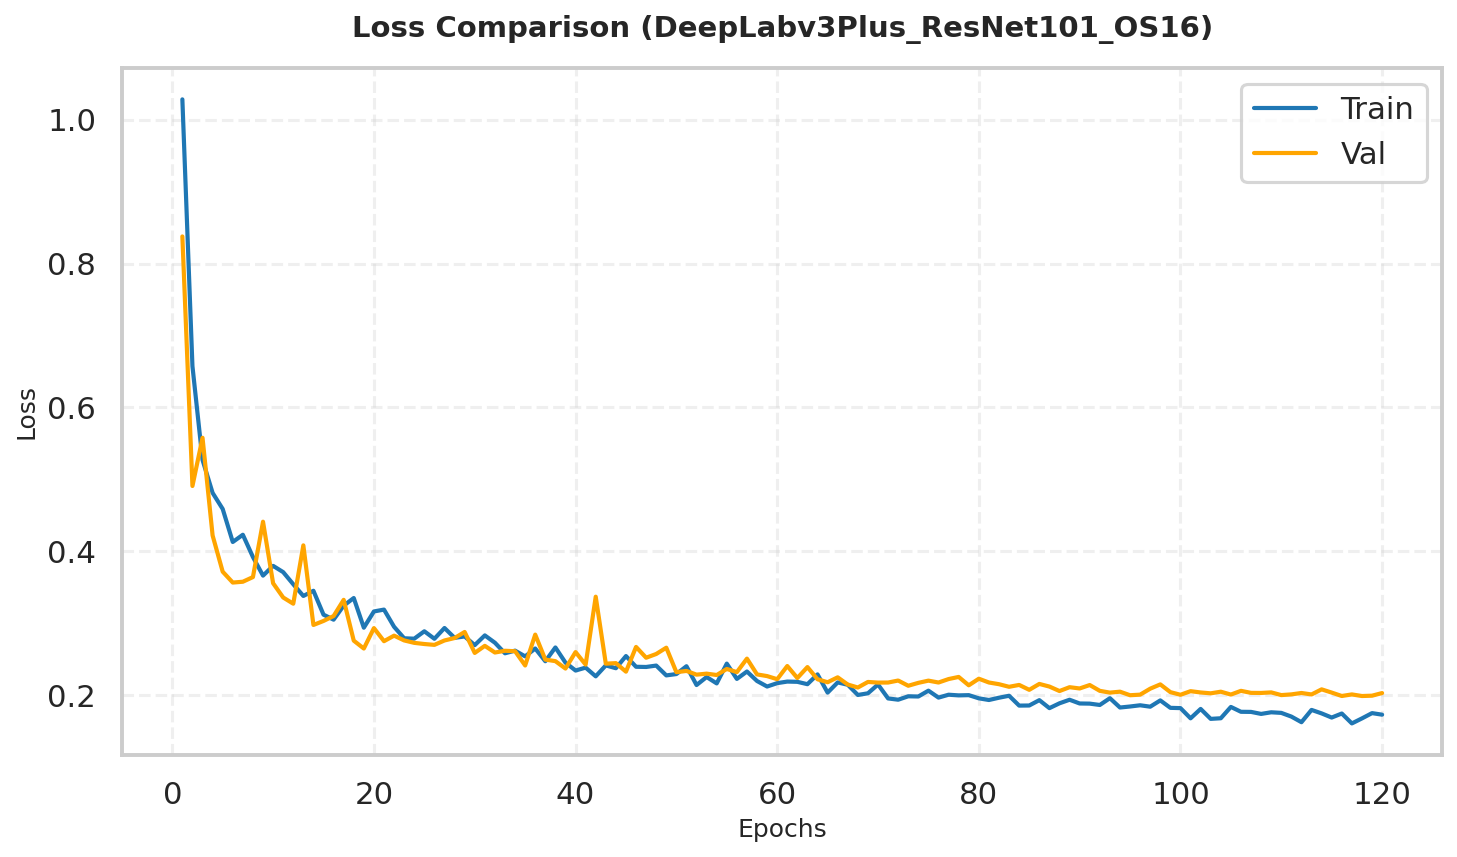

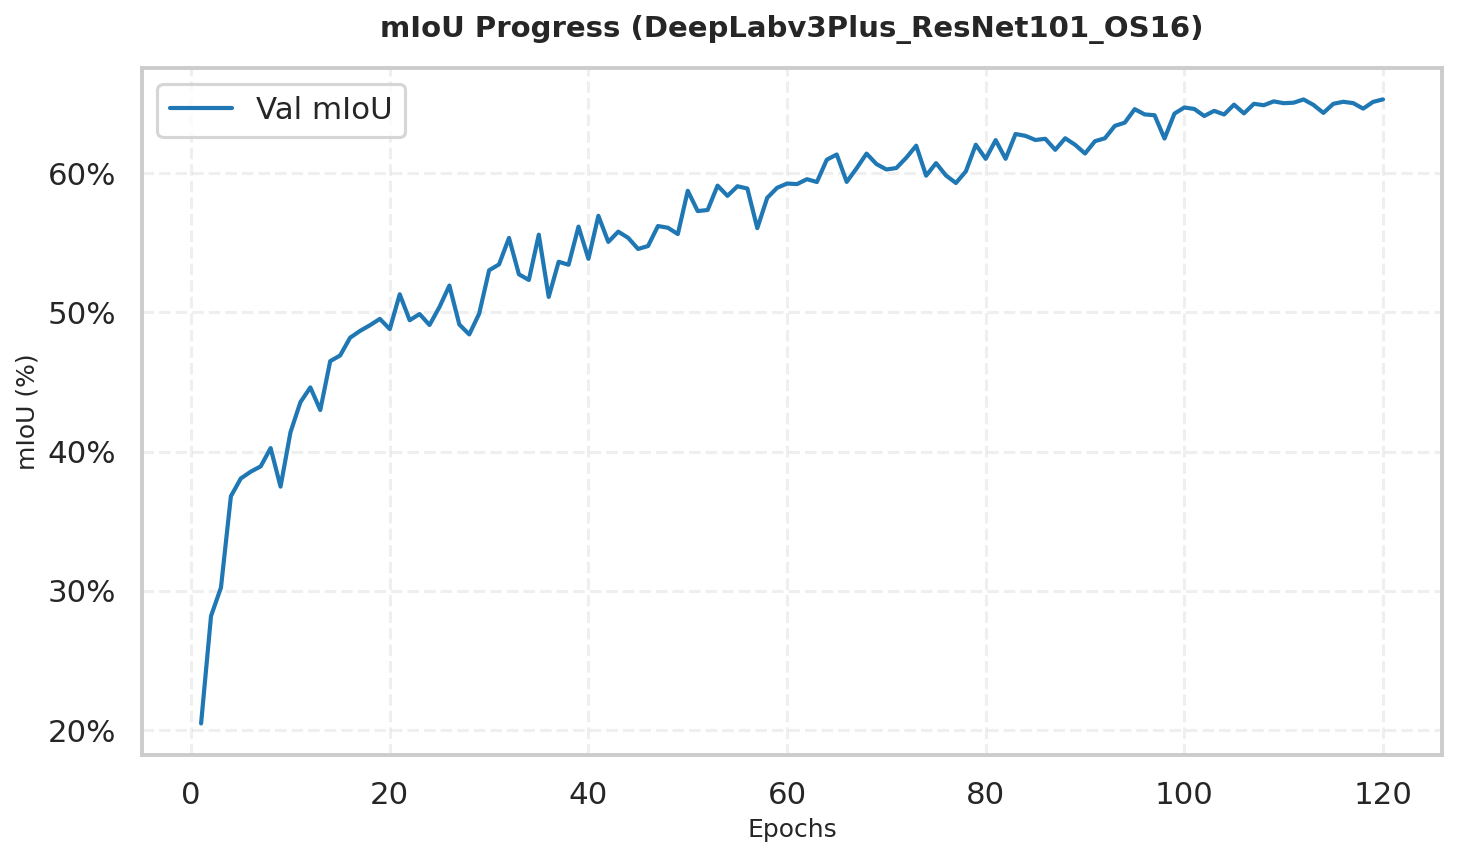

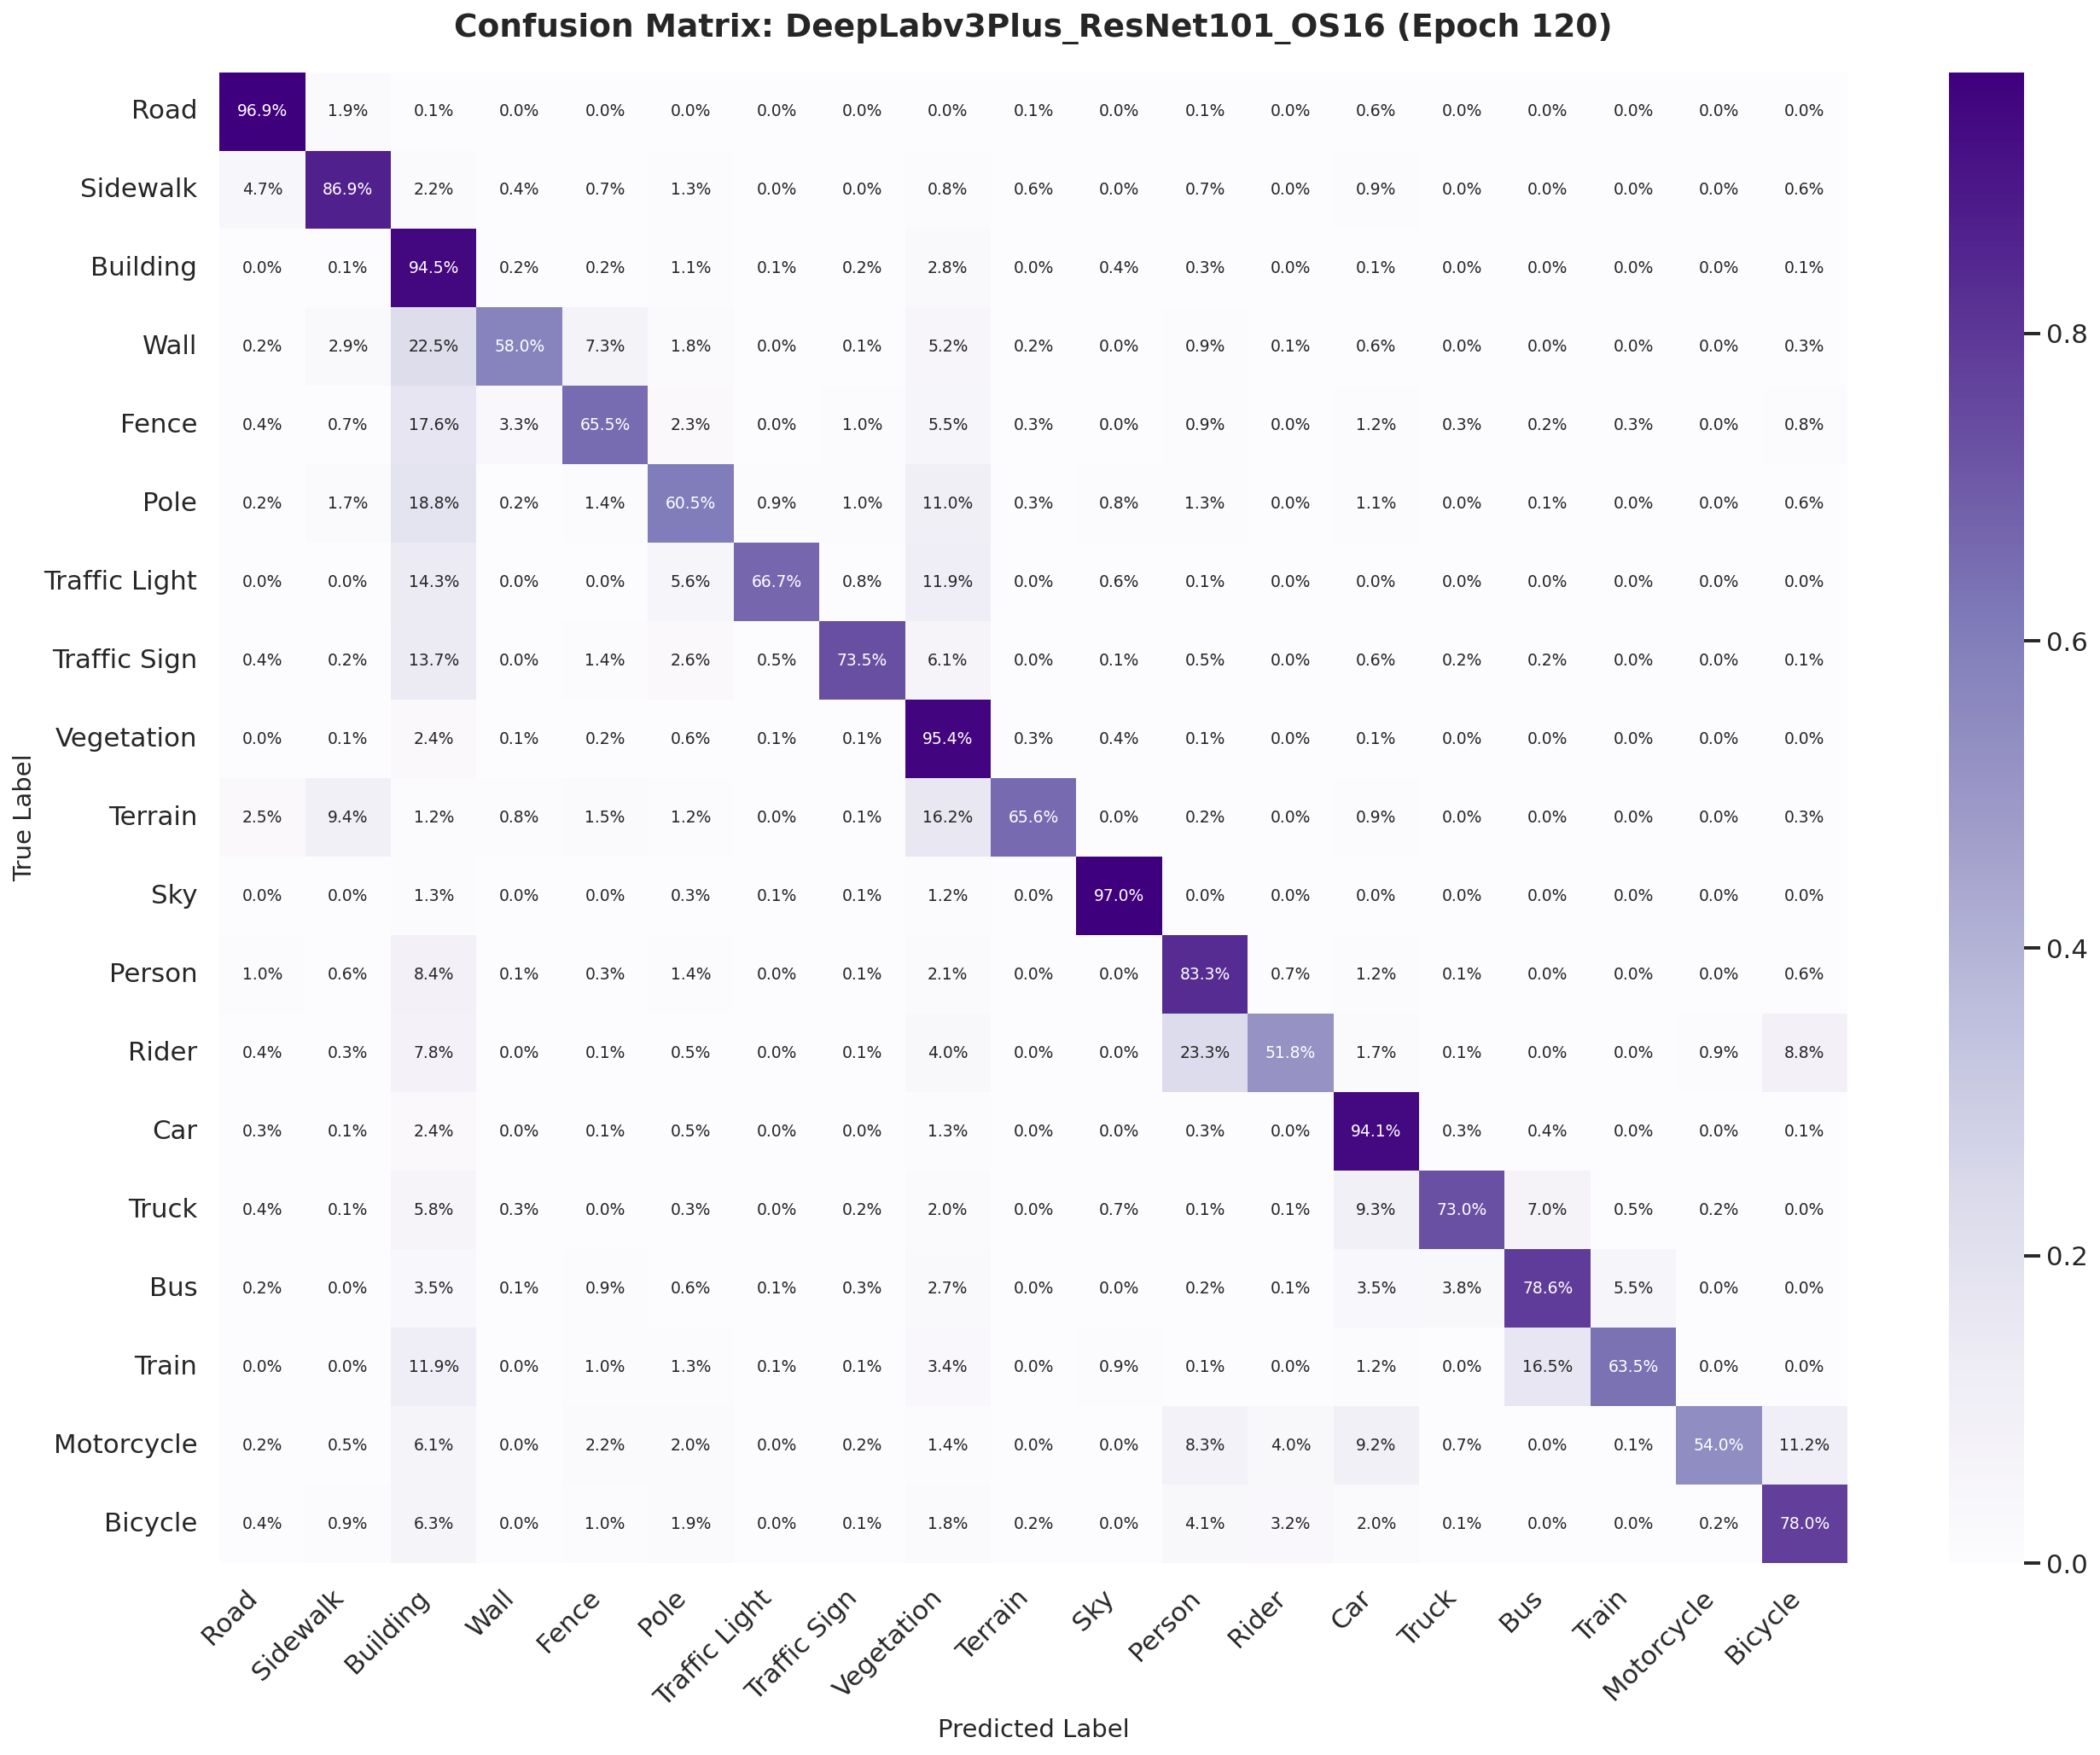


 EXPERIMENT TRACKER: DeepLabv3Plus_ResNet101_OS16 
Total Parameters:      45,687,747  (45.69 M)
Trainable Parameters:  45,687,747  (45.69 M)
------------------------------------------------------------
Best Validation mIoU:  65.30% (Epoch 120)
Final Epoch aAcc:      93.28%
Final Epoch mAcc:      75.31%
------------------------------------------------------------
CLASS NAME           | IoU (%)    | Accuracy (%)
------------------------------------------------------------
Road                 | 96.06      | 96.89     
Sidewalk             | 74.37      | 86.89     
Building             | 87.60      | 94.50     
Wall                 | 50.33      | 57.99     
Fence                | 50.89      | 65.46     
Pole                 | 43.47      | 60.49     
Traffic Light        | 52.35      | 66.70     
Traffic Sign         | 61.96      | 73.46     
Vegetation           | 88.74      | 95.41     
Terrain              | 57.40      | 65.55     
Sky                  | 91.96      | 96.99     
Person 

In [9]:
# ============================================================
# STEP 6: EXPERIMENT EXPORT & COMPARATIVE TRACKING
# Target Architecture: DeepLabv3+ (Strict Paper Implementation)
# Backbone: ResNet-101
# Optimized for: Isolated Run Folders and Master Ledgers
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force Jupyter to display plots inline
%matplotlib inline

# ------------------------------------------------------------
# 1. EXPERIMENT CONFIGURATION
# ------------------------------------------------------------
EXPERIMENT_NAME = "DeepLabv3Plus_ResNet101_OS16" 

MANUAL_TOTAL_TIME_STR = None # Auto-calculated from history if None

# ------------------------------------------------------------
# 2. SAFETY CHECKS & ISOLATED PATHS
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

# Create a master export directory, and an ISOLATED directory for this specific run
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
RUN_SAVE_DIR = MASTER_SAVE_DIR / EXPERIMENT_NAME

MASTER_SAVE_DIR.mkdir(parents=True, exist_ok=True)
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Master Directory: {MASTER_SAVE_DIR.resolve()}")
print(f"[*] Current Run Directory:     {RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# 3. ROBUST METRICS & MATRIX RECOVERY 
# ------------------------------------------------------------
def compute_metrics_fallback(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    
    return {
        "mIoU": float(mIoU), 
        "aAcc": float(aAcc), 
        "mAcc": float(mAcc), 
        "iou_per_class": iou_per_class, 
        "acc_per_class": acc_per_class
    }

# Force extraction of the best or latest matrix to guarantee class-wise metrics
matrix_to_use = globals().get("BEST_CONF_MATRIX", globals().get("val_conf_matrix"))

if matrix_to_use is not None:
    # Ensure it's a numpy array for the fallback calculation
    if torch.is_tensor(matrix_to_use):
        matrix_to_use = matrix_to_use.cpu().numpy()
        
    BEST_CONF_MATRIX = matrix_to_use
    BEST_METRICS = compute_metrics_fallback(BEST_CONF_MATRIX)
    print("[*] Successfully generated class-wise metrics from memory.")
else:
    BEST_CONF_MATRIX = None
    BEST_METRICS = None
    print("[!] Warning: No confusion matrix found in memory. Class-wise data cannot be generated.")

# ------------------------------------------------------------
# 4. BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))
if num_epochs == 0:
    num_epochs = len(history.get("train_total_loss", []))

def get_hist_col(keys):
    """Checks multiple possible dictionary keys to guarantee data is found"""
    if isinstance(keys, str): keys = [keys]
    for key in keys:
        col = history.get(key, [])
        if len(col) > 0:
            if len(col) == num_epochs: return col
            return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Loss": get_hist_col("train_total_loss"),
    "Val_Loss": get_hist_col("val_total_loss"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

if df["Epoch"].isna().all() and num_epochs > 0:
    df["Epoch"] = list(range(1, num_epochs + 1))

total_time_str = MANUAL_TOTAL_TIME_STR if MANUAL_TOTAL_TIME_STR else str(timedelta(seconds=int(df["Epoch_Time_sec"].sum(skipna=True))))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# 5. PREPARE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_METRICS is not None and "iou_per_class" in BEST_METRICS:
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": BEST_METRICS["iou_per_class"][i] * 100,
            "Accuracy (%)": BEST_METRICS["acc_per_class"][i] * 100
        })

# ------------------------------------------------------------
# 6. UPDATE MASTER EXPERIMENT LEDGER
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_v_acc = safe_pct(df["Val_aAcc"].iloc[-1]) if not df["Val_aAcc"].isna().all() else 0.0
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1]) if not df["Val_mIoU"].isna().all() else 0.0
final_mAcc = safe_pct(df["Val_mAcc"].iloc[-1]) if not df["Val_mAcc"].isna().all() else 0.0

if "val_miou" in history and len(history["val_miou"]) > 0:
    best_miou_raw = max(history["val_miou"])
    best_idx = history["val_miou"].index(best_miou_raw)
    best_epoch = history.get("epoch", list(range(1, num_epochs + 1)))[best_idx]
    best_miou = safe_pct(best_miou_raw)
else:
    best_epoch = best_record.get("best_epoch", -1)
    best_miou = safe_pct(best_record.get("best_miou", 0.0))

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create the summary dictionary for this specific run
run_summary = {
    "Experiment Name": EXPERIMENT_NAME,
    "Architecture": "DeepLabv3+",
    "Backbone": "ResNet-101",
    "Best Epoch": best_epoch,
    "Best Val mIoU (%)": round(best_miou, 2),
    "Final aAcc (%)": round(final_v_acc, 2),
    "Final mAcc (%)": round(final_mAcc, 2),
    "Total Params (M)": round(total_params / 1e6, 2),
    "Train Time": total_time_str
}

# Append to master ledger
ledger_path = MASTER_SAVE_DIR / "master_experiment_ledger.csv"
run_df = pd.DataFrame([run_summary])

if ledger_path.exists():
    master_df = pd.read_csv(ledger_path)
    if EXPERIMENT_NAME in master_df["Experiment Name"].values:
        master_df.set_index("Experiment Name", inplace=True)
        run_df.set_index("Experiment Name", inplace=True)
        master_df.update(run_df)
        master_df.reset_index(inplace=True)
    else:
        master_df = pd.concat([master_df, run_df], ignore_index=True)
    master_df.to_csv(ledger_path, index=False)
else:
    run_df.to_csv(ledger_path, index=False)

# Save detailed run files
run_df.to_csv(RUN_SAVE_DIR / "run_summary.csv", index=False)
try:
    with pd.ExcelWriter(RUN_SAVE_DIR / f"{EXPERIMENT_NAME}_Metrics.xlsx", engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
        if class_wise_data:
            pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise', index=False)
except ImportError: 
    pass  

# ------------------------------------------------------------
# 7. STANDARD SEPARATE PLOTS (Saved to Run Folder)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_and_show_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", filter_warmup=False):
    plt.figure(figsize=(10, 6))
    start_idx = 5 if filter_warmup and len(train_data) > 5 else 0
    epochs_range = range(start_idx + 1, len(train_data) + 1)
    
    train_clean = np.array(train_data, dtype=float)[start_idx:]
    plt.plot(epochs_range, train_clean, label=label1, lw=2)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)[start_idx:]
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, color='orange')
            
    if "(%)" in ylabel: plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}%".format(int(x))))
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(RUN_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

train_loss = df["Train_Loss"].tolist()
val_loss = df["Val_Loss"].tolist()

def ensure_pct(series):
    if series.isna().all(): return None
    return [x * 100 if (pd.notna(x) and x <= 1.0) else x for x in series.tolist()]

val_miou = ensure_pct(df["Val_mIoU"])

save_and_show_plot("loss_comparison", f"Loss Comparison ({EXPERIMENT_NAME})", "Loss", train_loss, val_loss)
if val_miou is not None:
    save_and_show_plot("miou_progress", f"mIoU Progress ({EXPERIMENT_NAME})", "mIoU (%)", val_miou, label1="Val mIoU")

# ------------------------------------------------------------
# 8. PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(18, 14)) 
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 9}) 
    
    plt.title(f"Confusion Matrix: {EXPERIMENT_NAME} (Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(RUN_SAVE_DIR / "confusion_matrix.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------------------
print(f"\n" + "="*60)
print(f" EXPERIMENT TRACKER: {EXPERIMENT_NAME} ")
print("="*60)
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print("-" * 60)
print(f"Best Validation mIoU:  {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch aAcc:      {final_v_acc:.2f}%")
print(f"Final Epoch mAcc:      {final_mAcc:.2f}%")
print("-" * 60)
print(f"{'CLASS NAME':<20} | {'IoU (%)':<10} | {'Accuracy (%)':<10}")
print("-" * 60)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<20} | {item['IoU (%)']:<10.2f} | {item['Accuracy (%)']:<10.2f}")
else:
    print("[!] No class-wise data available in memory to print.")

print("-" * 60)
print(f"[*] Ledger Updated: {ledger_path.resolve()}")
print(f"[*] Artifacts Saved: {RUN_SAVE_DIR.resolve()}")

In [10]:
import numpy as np

def compute_f1_precision_recall(conf_matrix: np.ndarray):
    """
    Calculates class-wise and macro-averaged Precision, Recall, and F1-Score 
    directly from a semantic segmentation confusion matrix.
    """
    # Extract True Positives, False Positives, and False Negatives
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    # Epsilon prevents division by zero for absent classes
    epsilon = 1e-10
    
    # Calculate Class-wise Metrics
    precision_per_class = tp / (tp + fp + epsilon)
    recall_per_class = tp / (tp + fn + epsilon)
    f1_per_class = (2 * tp) / ((2 * tp) + fp + fn + epsilon)
    
    # Calculate Macro Averages (Mean across all classes)
    macro_precision = np.nanmean(precision_per_class)
    macro_recall = np.nanmean(recall_per_class)
    macro_f1 = np.nanmean(f1_per_class)
    
    return {
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1)
    }

# --- Usage Example with your existing variables ---
# Assuming BEST_CONF_MATRIX is loaded in your Step 6 workspace
if BEST_CONF_MATRIX is not None:
    extra_metrics = compute_f1_precision_recall(BEST_CONF_MATRIX)
    print(f"Macro Precision: {extra_metrics['macro_precision'] * 100:.2f}%")
    print(f"Macro Recall:    {extra_metrics['macro_recall'] * 100:.2f}%")
    print(f"Macro F1-Score:  {extra_metrics['macro_f1'] * 100:.2f}%")

Macro Precision: 80.65%
Macro Recall:    75.60%
Macro F1-Score:  77.73%


[*] Presentation graph will be safely exported to:
/home/ubuntu/Pictures/deeplabv3+_cityscapes/Results_Export_deeplabv3+_cityscapes/DeepLabv3Plus_ResNet101_OS16
[*] Success! Graph preserved at:
/home/ubuntu/Pictures/deeplabv3+_cityscapes/Results_Export_deeplabv3+_cityscapes/DeepLabv3Plus_ResNet101_OS16/presentation_metrics_DeepLabv3Plus_ResNet101_OS16.png


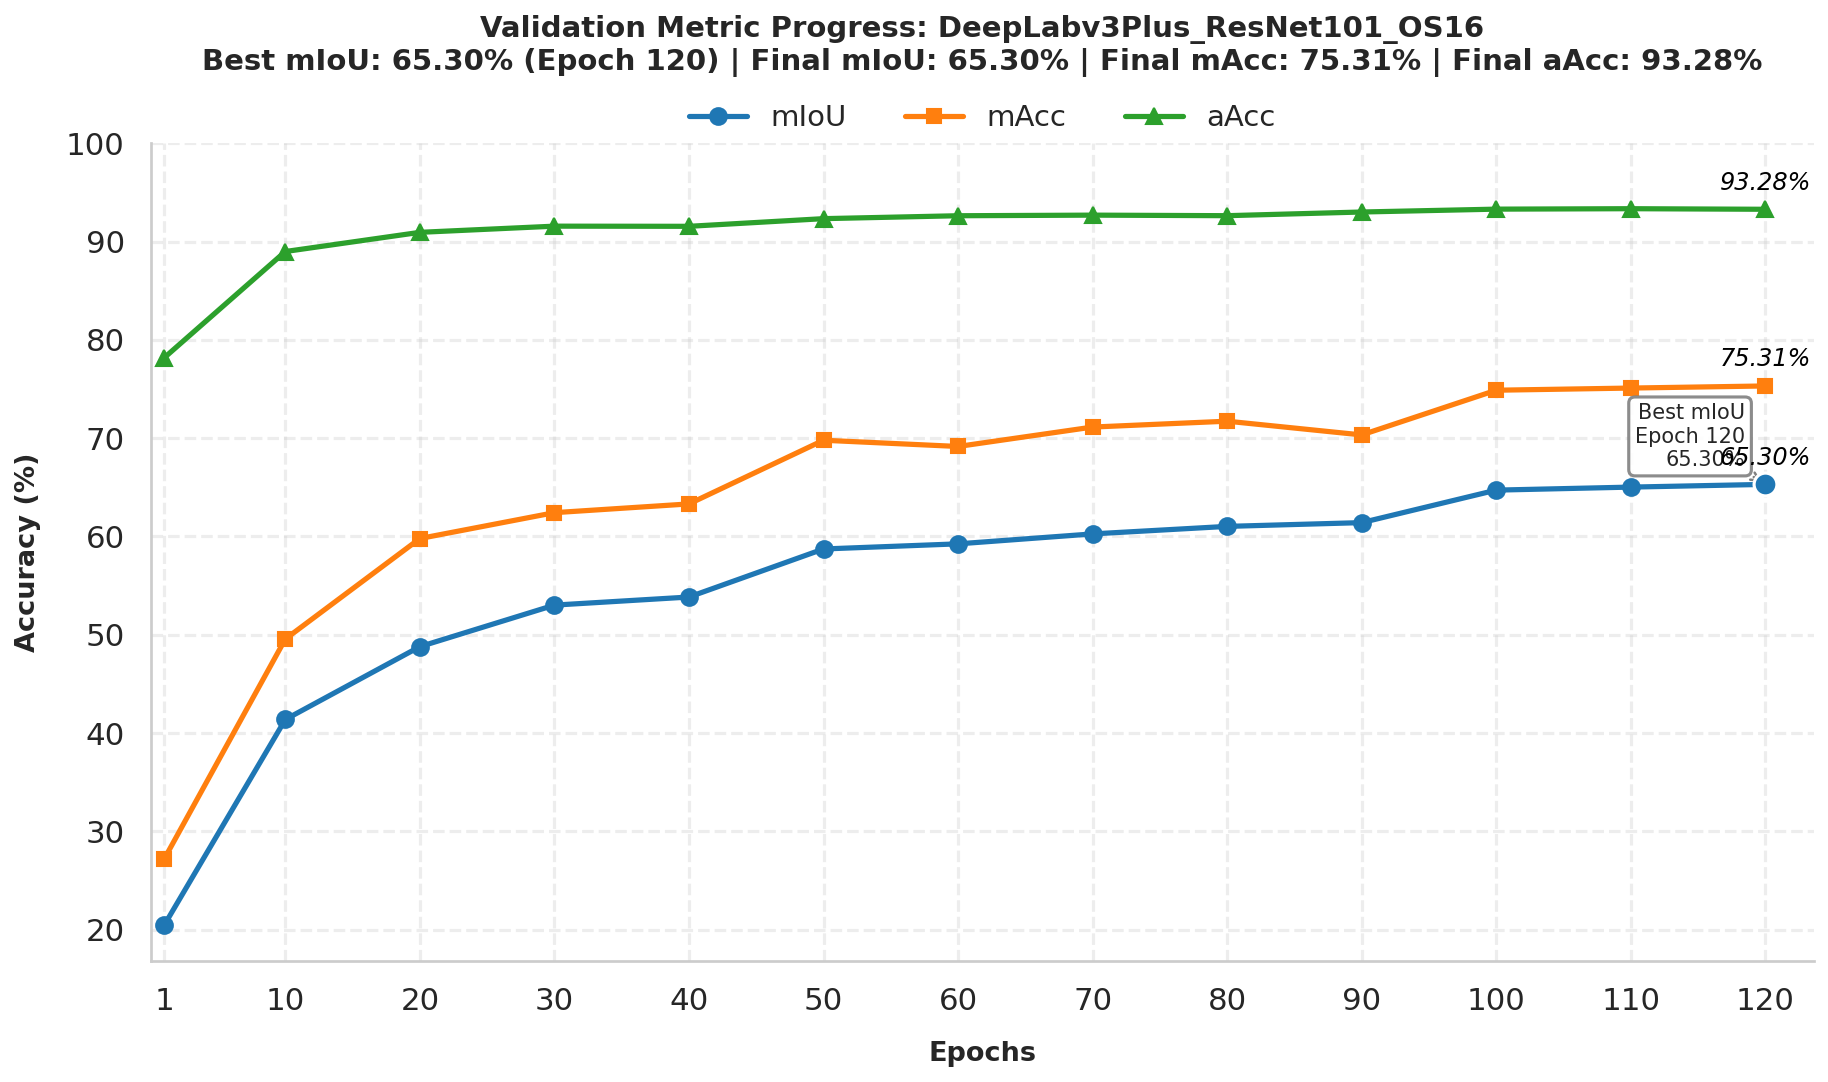

In [8]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# Target Architecture: DeepLabv3+ (Strict Paper Implementation)
# Backbone: ResNet-101
# Optimized for: Ablation Study Isolation, Specific Epoch Intervals,
# and Strict Percentage Scaling for Publication
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# SAFETY CHECKS & ABLATION PATH INHERITANCE
# ------------------------------------------------------------
required_globals = ["history"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training before Step 7.")

# Securely inherit the specific run directory and experiment name from Step 6
EXPERIMENT_NAME = globals().get("EXPERIMENT_NAME", "DeepLabv3Plus_ResNet101")
MASTER_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
RUN_SAVE_DIR = globals().get("RUN_SAVE_DIR", MASTER_SAVE_DIR / EXPERIMENT_NAME)

# Ensure the directory exists just in case
RUN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Presentation graph will be safely exported to:\n{RUN_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# PREPARE EPOCHS & DATA
# ------------------------------------------------------------
# Fallback generator if the explicit "epoch" list is missing from older checkpoints
num_epochs = len(history["val_miou"])
all_epochs = history.get("epoch", list(range(1, num_epochs + 1)))

# Safe percentage converter
def safe_pct(val):
    return val * 100.0 if val <= 1.0 else float(val)

# Bulletproof Best Epoch Extraction
best_miou_raw = max(history["val_miou"])
best_idx = history["val_miou"].index(best_miou_raw)
best_miou = safe_pct(best_miou_raw)
best_miou_epoch = all_epochs[best_idx]

# Filter epochs to reduce visual clutter: Epoch 1, every 10th epoch, best epoch, final epoch
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % 10 == 0] + [all_epochs[-1], best_miou_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages for cleaner presentation
miou_scores = [safe_pct(history["val_miou"][i]) for i in indices]
macc_scores = [safe_pct(history["val_macc"][i]) for i in indices]
aacc_scores = [safe_pct(history["val_aacc"][i]) for i in indices]

final_miou = safe_pct(history["val_miou"][-1])
final_macc = safe_pct(history["val_macc"][-1])
final_aacc = safe_pct(history["val_aacc"][-1])
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT SETUP 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)

# ------------------------------------------------------------
# BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + 1.5
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - 1.5
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.5),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# END-OF-LINE FINAL VALUE ANNOTATIONS (Floating above markers)
# ------------------------------------------------------------
offset_y = 1.5

ax.text(final_x, final_miou + offset_y, f'{final_miou:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_macc + offset_y, f'{final_macc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_aacc + offset_y, f'{final_aacc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')

ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.03))
ax.set_ylim(top=100) 

# ------------------------------------------------------------
# STYLING & LEGEND
# ------------------------------------------------------------
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

# Dynamically injecting the specific EXPERIMENT_NAME into the title
title_main = f"Validation Metric Progress: {EXPERIMENT_NAME}"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}) | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=35
)

plt.tight_layout()

# ------------------------------------------------------------
# ISOLATED RUN SAVE
# ------------------------------------------------------------
# Includes the specific experiment name in the PNG file for safe copying
combined_graph_path = RUN_SAVE_DIR / f"presentation_metrics_{EXPERIMENT_NAME}.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"[*] Success! Graph preserved at:\n{combined_graph_path.resolve()}")

plt.show()
plt.close()

In [11]:
# ============================================================
# STEP 8: POST-TRAINING VISUALIZATION EXPORT
# Generates side-by-side comparisons of Input, Target, and Prediction
# ============================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torchvision.transforms.functional as TF

# ------------------------------------------------------------
# 1. SAFETY CHECKS & EXACT PATH SETUP
# ------------------------------------------------------------
required_globals = ["model", "val_loader", "DEVICE", "CLASS_NAMES"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}")

# Establish the specific requested path
OUTPUT_DIR = globals().get("OUTPUT_DIR", Path("./Outputs"))
QUAL_VIS_DIR = OUTPUT_DIR / "training_visuals_deeplabv3+_cityscapes"
QUAL_VIS_DIR.mkdir(parents=True, exist_ok=True)

print(f"[*] Saving visualizations directly to: {QUAL_VIS_DIR.resolve()}")

# ------------------------------------------------------------
# 2. COLOR MAP GENERATOR FOR MASKS
# ------------------------------------------------------------
def get_color_map(num_classes):
    """Generates a distinct color palette for segmentation masks."""
    np.random.seed(42) # Fixed seed for consistent colors across runs
    colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)
    # Force background/void class (0) to be black if applicable
    colors[0] = [0, 0, 0] 
    return colors

COLOR_MAP = get_color_map(len(CLASS_NAMES))

def decode_mask_to_rgb(mask_2d, color_map):
    """Converts a 2D class index mask into an RGB image."""
    h, w = mask_2d.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_idx in range(len(color_map)):
        rgb_mask[mask_2d == class_idx] = color_map[class_idx]
    return rgb_mask

# ------------------------------------------------------------
# 3. VISUALIZATION ENGINE
# ------------------------------------------------------------
def save_evaluation_visuals(model, dataloader, device, save_dir, num_samples=5):
    """Runs inference on a few validation samples and plots the results."""
    model.eval()
    samples_processed = 0
    
    plt.ioff() # Turn off interactive plotting to prevent notebook clutter
    
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(dataloader):
            images = images.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # DeepLabv3+ output handling (if it returns a dict, grab the main output)
            if isinstance(outputs, dict):
                outputs = outputs['out']
                
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()
            images_cpu = images.cpu()
            masks_cpu = masks.cpu().numpy()
            
            batch_size = images.size(0)
            
            for i in range(batch_size):
                if samples_processed >= num_samples:
                    plt.ion()
                    return
                
                # Denormalize image for viewing (assuming standard ImageNet normalization)
                img = images_cpu[i].clone()
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img = img * std + mean 
                img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
                
                # Decode masks
                gt_rgb = decode_mask_to_rgb(masks_cpu[i], COLOR_MAP)
                pred_rgb = decode_mask_to_rgb(predictions[i], COLOR_MAP)
                
                # Plotting
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                axes[0].imshow(img)
                axes[0].set_title("Input Image", fontsize=14, fontweight='bold')
                axes[0].axis('off')
                
                axes[1].imshow(gt_rgb)
                axes[1].set_title("Ground Truth Mask", fontsize=14, fontweight='bold')
                axes[1].axis('off')
                
                axes[2].imshow(pred_rgb)
                axes[2].set_title("Model Prediction", fontsize=14, fontweight='bold')
                axes[2].axis('off')
                
                plt.tight_layout()
                save_path = save_dir / f"sample_{samples_processed + 1}.png"
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                plt.close(fig)
                
                print(f"[-] Saved visual {samples_processed + 1}/{num_samples}")
                samples_processed += 1

# ------------------------------------------------------------
# 4. EXECUTE
# ------------------------------------------------------------
print(f"--- Generating {5} Visual Comparisons ---")
save_evaluation_visuals(model, val_loader, DEVICE, QUAL_VIS_DIR, num_samples=5)
print(f"[*] All training visuals successfully stored in {QUAL_VIS_DIR.name}.")

[*] Saving visualizations directly to: /home/ubuntu/Pictures/deeplabv3+_cityscapes/training_visuals_deeplabv3+_cityscapes
--- Generating 5 Visual Comparisons ---
[-] Saved visual 1/5
[-] Saved visual 2/5
[-] Saved visual 3/5
[-] Saved visual 4/5
[-] Saved visual 5/5
[*] All training visuals successfully stored in training_visuals_deeplabv3+_cityscapes.
